In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading

In [ ]:
# Paths relative to notebooks/ directory
DATASET_DIR = Path("../dataset")
NORMAL_DIR = DATASET_DIR / "ai_normal"
ATTACK_DIR = DATASET_DIR / "ai_attack"

def load_dataset(folder: Path, label: int) -> pd.DataFrame:
    """Load all *_essential.csv files from a folder and assign label."""
    dfs = []
    for csv_path in sorted(folder.glob("*_essential.csv")):
        df = pd.read_csv(csv_path)
        extra = pd.DataFrame({"label": label, "source": csv_path.name}, index=df.index)
        dfs.append(pd.concat([df, extra], axis=1))
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def load_attack_stratified(normal_count: int, random_state: int = 42) -> pd.DataFrame:
    """Sample equal rows per attack type so high-volume types don't dominate.

    Each file contributes at most floor(normal_count / n_files) rows.
    Uses an explicit group loop instead of groupby().apply() to preserve the
    'source' column across all pandas versions (2.x drops it in apply()).
    """
    dfs = []
    for csv_path in sorted(ATTACK_DIR.glob("*_essential.csv")):
        df = pd.read_csv(csv_path)
        extra = pd.DataFrame({"label": 1, "source": csv_path.name}, index=df.index)
        dfs.append(pd.concat([df, extra], axis=1))
    attack_df = pd.concat(dfs, ignore_index=True)

    n_types = attack_df["source"].nunique()
    per_file = max(1, normal_count // n_types)  # ~60 rows/type for 2 719 normal / 45 types

    # Explicit group loop — avoids pandas 2.x groupby().apply() dropping 'source'
    sampled = pd.concat(
        [g.sample(n=min(len(g), per_file), random_state=random_state)
         for _, g in attack_df.groupby("source")],
        ignore_index=True,
    )
    if len(sampled) > normal_count:
        sampled = sampled.sample(n=normal_count, random_state=random_state)
    return sampled.reset_index(drop=True)

normal_df = load_dataset(NORMAL_DIR, label=0)
attack_df = load_attack_stratified(normal_count=len(normal_df))
n_attack_types = attack_df["source"].nunique()

dataset = pd.concat([normal_df, attack_df], ignore_index=True)

# Remove exact duplicates from overlapping capture sessions
before = len(dataset)
dedup_cols = [c for c in dataset.columns if c not in ("source", "label")]
dataset = dataset.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

print(f"Removed {before - len(dataset)} duplicate rows ({before} → {len(dataset)})")
print(f"Normal samples : {(dataset['label'] == 0).sum()}")
print(f"Attack samples : {(dataset['label'] == 1).sum()} across {n_attack_types} attack types")

## 3. Preprocessing

In [ ]:
# Drop non-feature metadata only — packet_type and direction are kept as signals
METADATA_COLS = ["timestamp", "message_index", "info"]
drop_cols = [c for c in METADATA_COLS if c in dataset.columns]
df_work = dataset.drop(columns=drop_cols)

# --- Value columns: drop those with >95% missing across the full dataset ---
all_value_cols = [c for c in df_work.columns if c.endswith("_value") and c != "label"]
missing_pct = (df_work[all_value_cols] == -1).mean()
keep_value_cols = missing_pct[missing_pct <= 0.95].index.tolist()
print(f"Kept {len(keep_value_cols)}/{len(all_value_cols)} value cols (≤95% missing)")

# --- Presence indicators: binary flag for each kept value column ---
# Whether a field was present in the packet is itself a signal —
# a tau_reject has a different set of populated fields than normal traffic.
presence_df = (df_work[keep_value_cols] != -1).astype(np.int8)
presence_df.columns = [f"{c}_present" for c in keep_value_cols]

# --- Categorical signal columns ---
signal_cat_cols = [c for c in ["packet_type", "direction"] if c in df_work.columns]

# --- Assemble full feature matrix ---
X = pd.concat(
    [df_work[keep_value_cols], presence_df, df_work[signal_cat_cols]],
    axis=1,
)
feature_cols = list(X.columns)
y = df_work["label"].values

print(f"Feature matrix shape  : {X.shape}")
print(f"  Value features      : {len(keep_value_cols)}")
print(f"  Presence indicators : {len(presence_df.columns)}")
print(f"  Categorical signals : {signal_cat_cols}")

In [ ]:
# Impute -1 sentinel with column median for value and categorical cols.
# Presence indicator columns are already binary (0/1) — skip them.
for col in keep_value_cols + signal_cat_cols:
    X[col] = X[col].replace(-1, np.nan)
    median_val = X[col].median()
    X[col] = X[col].fillna(0 if pd.isna(median_val) else median_val)

print(f"Imputation complete. Remaining NaN: {X.isna().any().any()}")

## 4. Train / Validation / Test Split

In [20]:
X_arr = X.values

# First split: 85% train+val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_arr, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: 70% train, 15% validation (of original)
# From 85% remaining: 70/85 ≈ 0.824 for train, 15/85 ≈ 0.176 for val
val_ratio = 0.15 / 0.85  # ~0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 3806, Val: 816, Test: 816


In [21]:
# MinMaxScaler: fit on training data only
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 5. Random Forest Training

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train_scaled, y_train)
print("Random Forest training complete.")

Random Forest training complete.


## 6. Evaluation and Visualization

In [23]:
# Validation set performance
y_val_pred = rf_model.predict(X_val_scaled)
print("Validation Set:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Normal", "Attack"]))

Validation Set:
Accuracy: 0.7353

Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.95      0.78       408
      Attack       0.91      0.52      0.66       408

    accuracy                           0.74       816
   macro avg       0.79      0.74      0.72       816
weighted avg       0.79      0.74      0.72       816



In [24]:
# Test set performance (final evaluation)
y_test_pred = rf_model.predict(X_test_scaled)
print("Test Set (Final):")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"]))

Test Set (Final):
Accuracy: 0.7696

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.96      0.81       408
      Attack       0.94      0.58      0.72       408

    accuracy                           0.77       816
   macro avg       0.82      0.77      0.76       816
weighted avg       0.82      0.77      0.76       816



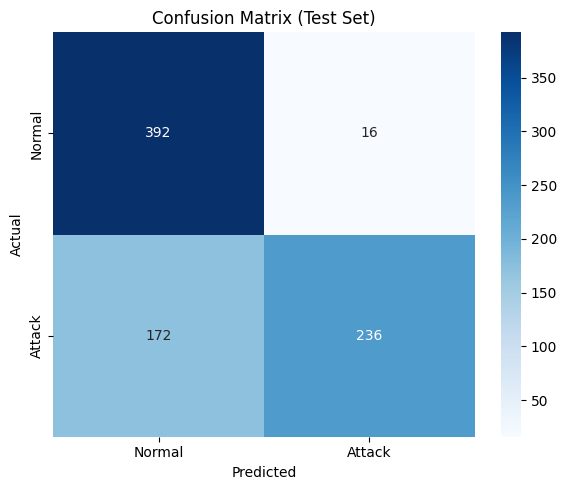

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

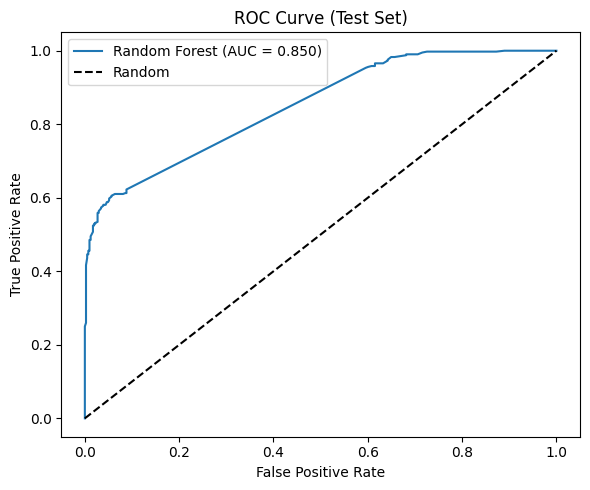

In [15]:
# ROC curve and AUC
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

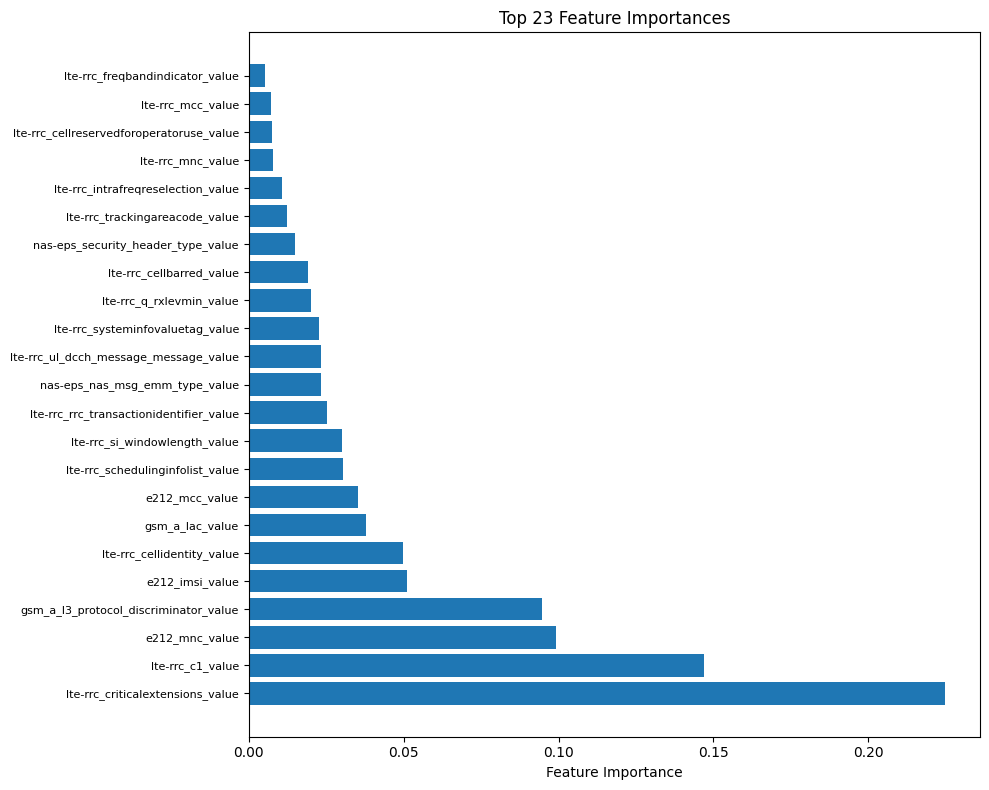

In [16]:
# Feature importance (top 25, or fewer if we have fewer features)
importance = rf_model.feature_importances_
n_top = min(25, len(feature_cols))
indices = np.argsort(importance)[::-1][:n_top]

plt.figure(figsize=(10, 8))
plt.barh(range(n_top), importance[indices][::-1], align="center")
plt.yticks(range(n_top), [feature_cols[i] for i in indices[::-1]], fontsize=8)
plt.xlabel("Feature Importance")
plt.title(f"Top {n_top} Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()